In [1]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import date
import numpy as np
import datetime

pd.options.display.max_rows = 999
pd.options.display.max_columns = 999

In [38]:
df_k9 = pd.read_csv("../H3K9me3-zhuojie-regions/data/zhuojie_c1_avglogfc.csv")
df_k9 = df_k9.rename(columns={"avg_logFC": "logFC_k9"})
df_k9.shape

(91, 5)

In [39]:
df_k9.head(1)

,tissue,cell_type,logFC_k9,num_up_peaks,num_down_peaks
0,brainCB,brainCB-GC_ExN,-1.565036,2,273


In [40]:
df_genes = pd.read_csv("../../../RNA/GSEA/data/ssgsea_scores.csv")
df_genes.shape

(6237, 388)

In [41]:
df_long = df_genes.melt(
    id_vars=["GO_ID", "Description"],
    var_name="celltype_age",
    value_name="score"
)
# 2️⃣ 拆分 cell type 和 age
df_long[["cell_type", "age"]] = df_long["celltype_age"].str.split("__", expand=True)

df_final = df_long.pivot_table(
    index=["GO_ID", "Description", "cell_type"],
    columns="age",
    values="score"
).reset_index()

# 4️⃣ 重命名列
df_final = df_final.rename(columns={
    "3m": "3m_score",
    "27m": "27m_score"
})


df_final.columns.name = None
df_final.head()

,GO_ID,Description,cell_type,27m_score,3m_score
0,GO:0000002,mitochondrial genome maintenance,BAT-ASPC,0.243963,0.245340
1,GO:0000002,mitochondrial genome maintenance,BAT-Adipocyte,0.283406,0.289495
2,GO:0000002,mitochondrial genome maintenance,BAT-B_cell,0.285775,0.303186
3,GO:0000002,mitochondrial genome maintenance,BAT-Brown_adipocyte,0.291837,0.301348
4,GO:0000002,mitochondrial genome maintenance,BAT-MSC,0.266660,0.251787


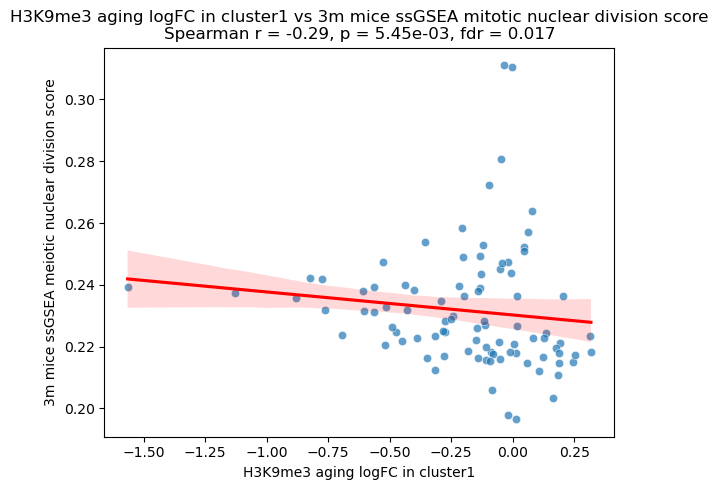

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

df_data = df_final[df_final["GO_ID"]=="GO:0140014"]
df_data = pd.merge(df_data, df_k9[["cell_type","logFC_k9"]], on=	"cell_type")

rho, pval = spearmanr(df_data['3m_score'], df_data['logFC_k9'])

# 画图
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df_data,
    x='logFC_k9',
    y='3m_score',
    alpha=0.7
)

# 加一条趋势线（可选）
sns.regplot(
    data=df_data,
     x='logFC_k9',
    y='3m_score',
    scatter=False,
    color='red'
)

# 标注相关性
plt.title(f'H3K9me3 aging logFC in cluster1 vs 3m mice ssGSEA mitotic nuclear division score\nSpearman r = {rho:.2f}, p = {pval:.2e}, fdr = 0.017')
plt.xlabel('H3K9me3 aging logFC in cluster1')
plt.ylabel('3m mice ssGSEA meiotic nuclear division score')

plt.tight_layout()
plt.show()

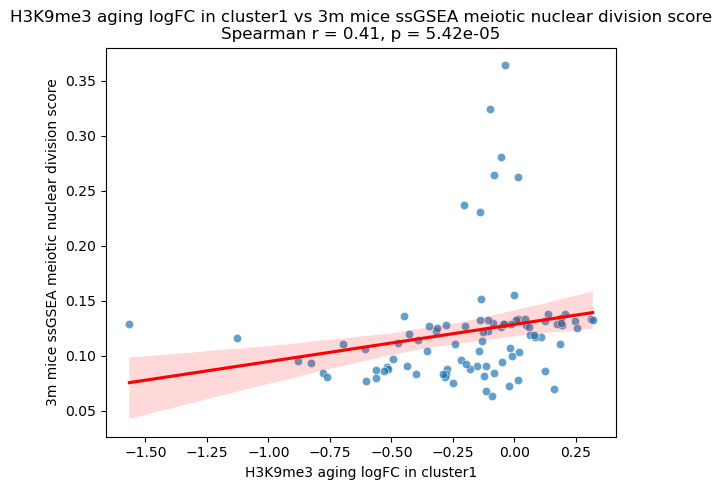

In [42]:


df_data = df_final[df_final["GO_ID"]=="GO:0140013"]
df_data = pd.merge(df_data, df_k9[["cell_type","logFC_k9"]], on=	"cell_type")

rho, pval = spearmanr(df_data['3m_score'], df_data['logFC_k9'])

# 画图
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df_data,
    x='logFC_k9',
    y='3m_score',
    alpha=0.7
)

# 加一条趋势线（可选）
sns.regplot(
    data=df_data,
     x='logFC_k9',
    y='3m_score',
    scatter=False,
    color='red'
)

# 标注相关性
plt.title(f'H3K9me3 aging logFC in cluster1 vs 3m mice ssGSEA meiotic nuclear division score\nSpearman r = {rho:.2f}, p = {pval:.2e}')
plt.xlabel('H3K9me3 aging logFC in cluster1')
plt.ylabel('3m mice ssGSEA meiotic nuclear division score')

plt.tight_layout()
plt.show()

In [16]:
df_gene = pd.read_csv("/storage/zhangyanxiaoLab/qihongjian/github/zhanglab-code/projects/paired_seq_tag/code/machine-experiments/RNA/GSEA/data/meiotic_nuclear_division_genes.csv")
df_gene = df_gene.drop_duplicates('SYMBOL')
df_gene.shape

(204, 4)

In [18]:
df_gene.head(1)


,GOALL,EVIDENCEALL,ONTOLOGYALL,SYMBOL
0,GO:0140013,IDA,BP,Birc5


In [21]:
df_cpm = pd.read_csv("/storage/zhangyanxiaoLab/qihongjian/github/zhanglab-code/projects/paired_seq_tag/code/machine-experiments/RNA/GSEA/data/aging_edgeR_results.csv")
df_cpm.shape

(1690523, 8)

In [22]:
df_cpm.head()

,gene,logFC,logCPM,LR,PValue,FDR,cell_type,tissue
0,0610009E02Rik,-0.121570,4.048035,0.373122,0.541308,0.770063,BAT-ASPC,BAT
1,0610010F05Rik,-0.115432,6.074431,0.596385,0.439961,0.697586,BAT-ASPC,BAT
2,0610030E20Rik,0.080692,4.200908,0.251768,0.615833,0.818185,BAT-ASPC,BAT
3,0610031O16Rik,-0.169517,3.191335,0.632773,0.426340,0.686467,BAT-ASPC,BAT
4,0610038B21Rik,0.249175,2.754197,1.026257,0.311039,0.587057,BAT-ASPC,BAT


In [26]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

results = []
for gene in df_gene["SYMBOL"]:
    df_gene_cpm = df_cpm[df_cpm["gene"] == gene].copy()
    df_gene_cpm = pd.merge(
        df_gene_cpm,
        df_k9[["cell_type", "logFC_k9"]],
        on="cell_type",
        how="inner"
    )
    df_gene_cpm["cpm"] = 2 ** df_gene_cpm["logCPM"]
    if df_gene_cpm.shape[0] < 10:
        continue
    
    rho, pval = spearmanr(
        df_gene_cpm["cpm"],
        df_gene_cpm["logFC_k9"]
    )
    
    results.append([gene, rho, pval])

# 转 dataframe
res_df = pd.DataFrame(results, columns=["gene", "spearman_r", "pval"])

In [27]:
res_df["FDR"] = multipletests(res_df["pval"], method="fdr_bh")[1]

In [30]:
res_df.sort_values("FDR").head(10)

,gene,spearman_r,pval,FDR
17,Smc2,0.503414,0.000005,0.000769
2,Brca2,0.463957,0.000013,0.001022
102,Mei4,0.498855,0.000027,0.001248
142,Morc2b,0.516399,0.000039,0.001248
151,Gm960,0.523308,0.000035,0.001248
7,Camk2b,0.413194,0.000063,0.001671
35,Siah1a,-0.413891,0.000091,0.002066
119,Ehmt2,0.406039,0.000115,0.002295
143,Mcmdc2,0.455813,0.000136,0.002400
121,Brdt,0.403414,0.000332,0.005282


In [32]:
df_gene_cpm.head(1)

,gene,logFC,logCPM,LR,PValue,FDR,cell_type,tissue,logFC_k9
0,Smc2,-0.381649,3.215142,2.304946,0.128963,0.363397,BAT-ASPC,BAT,-0.609428


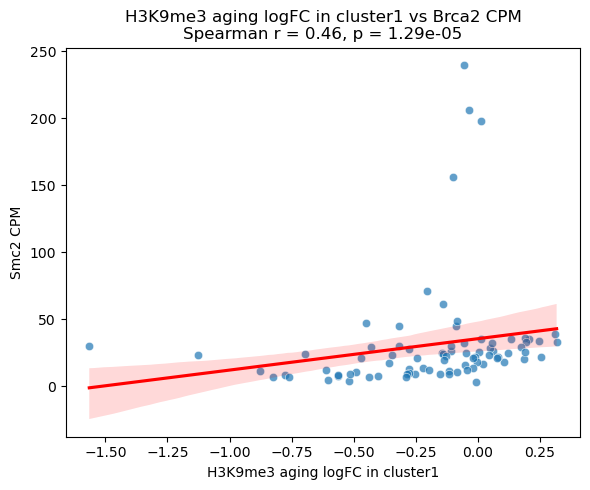

In [36]:
gene ="Brca2"
df_gene_cpm = df_cpm[df_cpm["gene"] == gene].copy()
df_gene_cpm["cpm"] = 2 ** df_gene_cpm["logCPM"]
df_gene_cpm = pd.merge( df_gene_cpm, df_k9[["cell_type", "logFC_k9"]], on="cell_type", how="inner" )


# 计算 Spearman correlation
rho, pval = spearmanr(df_gene_cpm['cpm'], df_gene_cpm['logFC_k9'])

# 画图
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df_gene_cpm,
    x='logFC_k9',
    y='cpm',
    alpha=0.7
)

# 加一条趋势线（可选）
sns.regplot(
    data=df_gene_cpm,
     x='logFC_k9',
    y='cpm',
    scatter=False,
    color='red'
)

# 标注相关性
plt.title(f'H3K9me3 aging logFC in cluster1 vs {gene} CPM\nSpearman r = {rho:.2f}, p = {pval:.2e}')
plt.xlabel('H3K9me3 aging logFC in cluster1')
plt.ylabel('Smc2 CPM')

plt.tight_layout()
plt.show()